# INFEST XII Data Science 2026 — V3 Conditional Trio Specialist

Notebook ini mengimplementasikan rancangan V3 hasil audit eksperimen sebelumnya secara end-to-end. Model utama **tidak diubah** dari baseline yang telah memperoleh Public LB **0.96082**: ImageNet-pretrained EfficientNet-B0, full fine-tuning, input `128×512`, 5-fold Stratified CV, CrossEntropy dengan label smoothing, dan probability averaging antar-fold.

Perubahan V3 hanya menargetkan bottleneck yang telah teridentifikasi pada kelas **Jawa, Jawi, dan Pegon**. Sebuah specialist EfficientNet-B0 dilatih pada tiga kelas tersebut dengan input beresolusi lebih tinggi `160×960`, menggunakan **fold assignment yang identik** dengan model utama. Specialist tidak boleh mengubah total probability mass yang diberikan model utama kepada trio tersebut; ia hanya meredistribusikan probability mass di dalam trio menggunakan conditional geometric fusion.

Pemilihan bobot fusion `alpha` dilakukan hanya dari OOF pada grid tetap `{0, 0.25, 0.5, 0.75, 1.0}`. Notebook juga menjalankan acceptance gate yang telah ditetapkan sebelumnya: peningkatan OOF harus meaningful, muncul konsisten lintas fold, dan meningkatkan diskriminasi Jawa/Jawi/Pegon. Tidak ada pseudo-labeling, data eksternal, manual override, atau eksperimen tambahan.

**Struktur folder** yang diharapkan:

```text
project-root/
├── INFEST_XII_v3_Conditional_Trio_Specialist_RTX4090.ipynb
└── data/
    ├── train.csv
    ├── test.csv
    ├── sample_submission.csv
    └── images/
        ├── train/
        └── test/
```

In [1]:
# ============================================================
# 1. Imports, konfigurasi, reproducibility, dan GPU preflight
# ============================================================

import os
import gc
import math
import json
import random
import hashlib
import warnings
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError

import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

warnings.filterwarnings('ignore')

SEED = 42
N_SPLITS = 5

# --------------------------
# Main V1 model: frozen methodology
# --------------------------
MAIN_IMG_H = 128
MAIN_IMG_W = 512
MAIN_TRAIN_BATCH = 64
MAIN_EVAL_BATCH = 256

# --------------------------
# V3 trio specialist
# --------------------------
SPECIALIST_IMG_H = 160
SPECIALIST_IMG_W = 960
# Resolusi ~2.34x pixel V1; 32 dipilih untuk margin VRAM aman pada RTX 4090 24 GB.
# Tidak ada gradient accumulation agar perilaku BatchNorm tetap transparan.
SPECIALIST_TRAIN_BATCH = 32
SPECIALIST_EVAL_BATCH = 128
TRIO_CLASSES = ['jawa', 'jawi', 'pegon']
ALPHA_GRID = [0.0, 0.25, 0.50, 0.75, 1.0]

# --------------------------
# Shared optimization config
# --------------------------
NUM_WORKERS = min(8, max(1, os.cpu_count() or 1))
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
WARMUP_EPOCHS = 1
BACKBONE_LR = 2e-4
HEAD_LR = 8e-4
MIN_LR_RATIO = 0.05
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
GRAD_CLIP_NORM = 1.0
USE_AMP = True
SAVE_FOLD_CHECKPOINTS = True

# Acceptance gate yang telah disepakati dari audit sebelumnya.
MIN_V3_OOF_F1 = 0.9860
MIN_POSITIVE_FOLDS = 4

PROJECT_ROOT = Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'infest_v3_trio_specialist'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int = SEED) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Dipertahankan dari baseline agar validation comparison tetap fair.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

if not torch.cuda.is_available():
    raise RuntimeError('CUDA GPU tidak terdeteksi. Notebook V3 dirancang untuk 1x NVIDIA RTX 4090.')
if torch.cuda.device_count() != 1:
    print(f'Peringatan: terdeteksi {torch.cuda.device_count()} GPU; notebook hanya menggunakan cuda:0.')

DEVICE = torch.device('cuda:0')
torch.cuda.set_device(DEVICE)
if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

GPU_NAME = torch.cuda.get_device_name(0)
GPU_PROPS = torch.cuda.get_device_properties(0)
GPU_VRAM_GB = GPU_PROPS.total_memory / (1024 ** 3)

print(f'Project root   : {PROJECT_ROOT}')
print(f'PyTorch        : {torch.__version__}')
print(f'CUDA runtime   : {torch.version.cuda}')
print(f'GPU            : {GPU_NAME}')
print(f'VRAM           : {GPU_VRAM_GB:.1f} GB')
print(f'Compute cap.   : {GPU_PROPS.major}.{GPU_PROPS.minor}')
print(f'Workers        : {NUM_WORKERS}')
print(f'Output dir     : {OUTPUT_DIR}')

# Tiny CUDA preflight agar incompatibility environment gagal sebelum training fold 1.
try:
    _x = torch.randn(8, 3, 32, 32, device=DEVICE)
    _conv = nn.Conv2d(3, 8, 3, padding=1).to(DEVICE)
    with torch.no_grad():
        _y = _conv(_x)
    torch.cuda.synchronize()
    del _x, _conv, _y
    torch.cuda.empty_cache()
    print('CUDA preflight : OK')
except Exception as exc:
    raise RuntimeError('CUDA preflight gagal. Periksa driver/PyTorch/CUDA image Vast.ai.') from exc

Project root   : /workspace
PyTorch        : 2.11.0+cu128
CUDA runtime   : 12.8
GPU            : NVIDIA GeForce RTX 5090
VRAM           : 31.4 GB
Compute cap.   : 12.0
Workers        : 8
Output dir     : /workspace/infest_v3_trio_specialist
CUDA preflight : OK


## 2. Dataset discovery dan integrity check

Tahap ini hanya memvalidasi dataset resmi. Satu file train yang rusak/0-byte akan dikeluarkan secara deterministik sebagaimana baseline V1. Test set harus lengkap dan valid agar submission tetap memiliki tepat satu prediksi untuk setiap `image_id`.

In [2]:
# ============================================================
# 2. Dataset discovery dan validation
# ============================================================

REQUIRED_FILES = {'train.csv', 'test.csv', 'sample_submission.csv'}


def is_dataset_root(root: Path) -> bool:
    return (
        root.is_dir()
        and all((root / name).is_file() for name in REQUIRED_FILES)
        and (root / 'images' / 'train').is_dir()
        and (root / 'images' / 'test').is_dir()
    )


def find_dataset_root(base_dir: Path) -> Path:
    base_dir = Path(base_dir).resolve()
    if not base_dir.exists():
        raise FileNotFoundError(
            f'Folder dataset tidak ditemukan: {base_dir}\n'
            'Letakkan dataset di ./data dengan train.csv, test.csv, sample_submission.csv, '
            'images/train, dan images/test.'
        )
    if is_dataset_root(base_dir):
        return base_dir

    candidates = []
    for train_csv in base_dir.rglob('train.csv'):
        root = train_csv.parent
        if is_dataset_root(root):
            candidates.append(root)
    candidates = list(dict.fromkeys(candidates))
    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) > 1:
        candidates = sorted(candidates, key=lambda p: (p / 'train.csv').stat().st_size, reverse=True)
        print('Beberapa candidate dataset root ditemukan. Menggunakan:', candidates[0])
        return candidates[0]
    raise FileNotFoundError('Struktur dataset INFEST tidak ditemukan di ./data.')


DATA_ROOT = find_dataset_root(DATA_DIR)
TRAIN_IMG_DIR = DATA_ROOT / 'images' / 'train'
TEST_IMG_DIR = DATA_ROOT / 'images' / 'test'

train_df = pd.read_csv(DATA_ROOT / 'train.csv')
test_df = pd.read_csv(DATA_ROOT / 'test.csv')
sample_submission = pd.read_csv(DATA_ROOT / 'sample_submission.csv')

assert list(train_df.columns) == ['image_id', 'label']
assert list(test_df.columns) == ['image_id']
assert list(sample_submission.columns) == ['image_id', 'label']
assert train_df['image_id'].is_unique
assert test_df['image_id'].is_unique
assert set(sample_submission['image_id']) == set(test_df['image_id'])

print(f'Data root       : {DATA_ROOT}')
print(f'Train rows raw  : {len(train_df):,}')
print(f'Test rows       : {len(test_df):,}')
print('\nDistribusi kelas train raw:')
print(train_df['label'].value_counts().sort_index())


def validate_image_file(path: Path):
    if not path.exists():
        return False, 'missing'
    if path.stat().st_size == 0:
        return False, 'zero_byte'
    try:
        with Image.open(path) as img:
            img.verify()
        return True, 'ok'
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        return False, type(exc).__name__


def audit_dataframe_images(df: pd.DataFrame, image_dir: Path) -> pd.DataFrame:
    bad = []
    for image_id in df['image_id'].tolist():
        ok, reason = validate_image_file(image_dir / image_id)
        if not ok:
            bad.append({'image_id': image_id, 'reason': reason})
    return pd.DataFrame(bad, columns=['image_id', 'reason'])


bad_train = audit_dataframe_images(train_df, TRAIN_IMG_DIR)
bad_test = audit_dataframe_images(test_df, TEST_IMG_DIR)

if len(bad_train):
    print('\nTrain image invalid yang dikeluarkan:')
    display(bad_train)
    train_df = train_df.loc[~train_df['image_id'].isin(bad_train['image_id'])].reset_index(drop=True)
else:
    print('\nTidak ada train image invalid.')

if len(bad_test):
    display(bad_test)
    raise RuntimeError('Terdapat test image invalid. Submission lengkap tidak dapat dibuat dengan aman.')

CLASSES = sorted(train_df['label'].unique().tolist())
CLASS_TO_IDX = {label: i for i, label in enumerate(CLASSES)}
IDX_TO_CLASS = {i: label for label, i in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CLASSES)
train_df['target'] = train_df['label'].map(CLASS_TO_IDX).astype(int)

assert NUM_CLASSES == 7
assert all(c in CLASS_TO_IDX for c in TRIO_CLASSES)
TRIO_GLOBAL_IDX = np.array([CLASS_TO_IDX[c] for c in TRIO_CLASSES], dtype=int)
TRIO_TO_IDX = {label: i for i, label in enumerate(TRIO_CLASSES)}
TRIO_IDX_TO_CLASS = {i: label for label, i in TRIO_TO_IDX.items()}

# Fold assignment dibuat SEKALI dan dipakai identik oleh main model dan specialist.
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
FOLDS = list(skf.split(train_df, train_df['target']))
fold_assignment = np.full(len(train_df), -1, dtype=np.int16)
for fold, (_, valid_idx) in enumerate(FOLDS, start=1):
    fold_assignment[valid_idx] = fold
assert (fold_assignment > 0).all()

fold_df = train_df[['image_id', 'label']].copy()
fold_df['fold'] = fold_assignment
fold_df.to_csv(OUTPUT_DIR / 'fold_assignment.csv', index=False)

print(f'\nTrain rows valid: {len(train_df):,}')
print(f'Classes ({NUM_CLASSES}): {CLASSES}')
print(f'Trio specialist : {TRIO_CLASSES}')
print('\nDistribusi kelas train valid:')
print(train_df['label'].value_counts().reindex(CLASSES))
print('\nFold x label counts:')
display(pd.crosstab(fold_df['fold'], fold_df['label']).reindex(columns=CLASSES))

Data root       : /workspace/data
Train rows raw  : 4,468
Test rows       : 1,118

Distribusi kelas train raw:
label
bali       367
jawa       653
jawi       814
lampung    823
lontara    382
pegon      771
sunda      658
Name: count, dtype: int64

Train image invalid yang dikeluarkan:


,image_id,reason
0,mPmaODVU.png,zero_byte



Train rows valid: 4,467
Classes (7): ['bali', 'jawa', 'jawi', 'lampung', 'lontara', 'pegon', 'sunda']
Trio specialist : ['jawa', 'jawi', 'pegon']

Distribusi kelas train valid:
label
bali       367
jawa       653
jawi       814
lampung    822
lontara    382
pegon      771
sunda      658
Name: count, dtype: int64

Fold x label counts:


label,bali,jawa,jawi,lampung,lontara,pegon,sunda
fold,,,,,,,
1,74,131,162,164,77,155,131
2,74,131,163,164,77,154,131
3,73,131,163,164,76,154,132
4,73,130,163,165,76,154,132
5,73,130,163,165,76,154,132


## 3. Preprocessing dan dataset

Main model memakai preprocessing V1 tanpa perubahan: aspect-ratio-preserving letterbox ke `128×512`, augmentasi dokumen konservatif, dan normalisasi ImageNet. Specialist memakai transform identik secara konseptual tetapi canvas `160×960`, sehingga detail stroke pada text line Jawa/Jawi/Pegon dipertahankan lebih baik.

In [3]:
# ============================================================
# 3. Transform dan Dataset
# ============================================================

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


class Letterbox:
    def __init__(self, size, fill=(255, 255, 255)):
        self.out_h, self.out_w = size
        self.fill = fill

    def __call__(self, image: Image.Image) -> Image.Image:
        image = image.convert('RGB')
        w, h = image.size
        if w <= 0 or h <= 0:
            raise ValueError(f'Ukuran gambar tidak valid: {(w, h)}')
        scale = min(self.out_w / w, self.out_h / h)
        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))
        image = image.resize((new_w, new_h), resample=Image.Resampling.BICUBIC)
        canvas = Image.new('RGB', (self.out_w, self.out_h), self.fill)
        left = (self.out_w - new_w) // 2
        top = (self.out_h - new_h) // 2
        canvas.paste(image, (left, top))
        return canvas


def build_transforms(height: int, width: int):
    train_transform = T.Compose([
        Letterbox((height, width)),
        T.RandomAffine(
            degrees=2.5,
            translate=(0.02, 0.03),
            scale=(0.95, 1.05),
            interpolation=T.InterpolationMode.BILINEAR,
            fill=(255, 255, 255),
        ),
        T.RandomApply([T.ColorJitter(brightness=0.08, contrast=0.10)], p=0.30),
        T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))], p=0.10),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    valid_transform = T.Compose([
        Letterbox((height, width)),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return train_transform, valid_transform


main_train_transform, main_valid_transform = build_transforms(MAIN_IMG_H, MAIN_IMG_W)
specialist_train_transform, specialist_valid_transform = build_transforms(SPECIALIST_IMG_H, SPECIALIST_IMG_W)


class AksaraDataset(Dataset):
    def __init__(self, df, image_dir, transform, target_column=None):
        self.df = df.reset_index(drop=True).copy()
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.target_column = target_column

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = self.image_dir / row['image_id']
        with Image.open(path) as image:
            image = self.transform(image.convert('RGB'))
        if self.target_column is None:
            return image
        return image, int(row[self.target_column])


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_loader(dataset, batch_size, shuffle, seed, drop_last=False):
    generator = torch.Generator()
    generator.manual_seed(seed)
    kwargs = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=drop_last,
        worker_init_fn=seed_worker,
        generator=generator,
    )
    if NUM_WORKERS > 0:
        kwargs.update(persistent_workers=True, prefetch_factor=2)
    return DataLoader(**kwargs)

## 4. Model dan training utilities

Kedua model menggunakan ImageNet-pretrained EfficientNet-B0 dengan full fine-tuning. Optimizer, learning-rate groups, warmup + cosine schedule, AMP, gradient clipping, label smoothing, dan early stopping dipertahankan dari baseline. Tidak ada class weighting atau weighted sampler.

In [4]:
# ============================================================
# 4. Model, optimizer, scheduler, training utilities
# ============================================================

OFFICIAL_TORCHVISION_WEIGHT_NAME = 'efficientnet_b0_rwightman-7f5810bc.pth'


def find_local_pretrained_weight():
    for root in [PROJECT_ROOT, DATA_DIR]:
        if root.exists():
            exact = list(root.rglob(OFFICIAL_TORCHVISION_WEIGHT_NAME))
            if exact:
                return exact[0]
    return None


def build_model(num_classes: int):
    try:
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    except Exception as exc:
        local_weight = find_local_pretrained_weight()
        if local_weight is None:
            raise RuntimeError(
                'Gagal memuat ImageNet pretrained EfficientNet-B0. Aktifkan internet pada instance Vast.ai '
                'atau letakkan official torchvision weight di project/data.'
            ) from exc
        print(f'Memuat pretrained weight lokal: {local_weight}')
        model = efficientnet_b0(weights=None)
        state = torch.load(local_weight, map_location='cpu')
        model.load_state_dict(state, strict=True)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def build_optimizer(model):
    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith('classifier.'):
            head_params.append(param)
        else:
            backbone_params.append(param)
    if not backbone_params or not head_params:
        raise RuntimeError('Parameter group backbone/head tidak terbentuk.')
    return AdamW(
        [
            {'params': backbone_params, 'lr': BACKBONE_LR},
            {'params': head_params, 'lr': HEAD_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )


def build_scheduler(optimizer, steps_per_epoch: int):
    total_steps = max(1, MAX_EPOCHS * steps_per_epoch)
    warmup_steps = max(1, WARMUP_EPOCHS * steps_per_epoch)

    def lr_lambda(step):
        if step < warmup_steps:
            return max(1e-3, (step + 1) / warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        progress = min(max(progress, 0.0), 1.0)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return MIN_LR_RATIO + (1.0 - MIN_LR_RATIO) * cosine

    return LambdaLR(optimizer, lr_lambda=lr_lambda)


def amp_context():
    if not USE_AMP:
        return nullcontext()
    if hasattr(torch, 'amp') and hasattr(torch.amp, 'autocast'):
        return torch.amp.autocast(device_type='cuda', dtype=torch.float16)
    return torch.cuda.amp.autocast(dtype=torch.float16)


def make_grad_scaler():
    if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler'):
        try:
            return torch.amp.GradScaler('cuda', enabled=USE_AMP)
        except TypeError:
            pass
    return torch.cuda.amp.GradScaler(enabled=USE_AMP)


def move_images_to_device(images):
    return images.to(DEVICE, non_blocking=True).contiguous()


def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler):
    model.train()
    running_loss = 0.0
    n_samples = 0
    for images, targets in loader:
        images = move_images_to_device(images)
        targets = targets.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with amp_context():
            logits = model(images)
            loss = criterion(logits, targets)
        if not torch.isfinite(loss):
            raise FloatingPointError(f'Loss non-finite: {loss.detach().item()}')
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        bs = targets.size(0)
        running_loss += loss.detach().item() * bs
        n_samples += bs
    return running_loss / max(1, n_samples)


@torch.inference_mode()
def predict_loader(model, loader, with_targets=True):
    model.eval()
    probs_all, targets_all = [], []
    for batch in loader:
        if with_targets:
            images, targets = batch
            targets_all.append(targets.numpy())
        else:
            images = batch
        images = move_images_to_device(images)
        with amp_context():
            logits = model(images)
        probs_all.append(torch.softmax(logits.float(), dim=1).cpu().numpy())
    if not probs_all:
        raise RuntimeError('DataLoader kosong.')
    probs_all = np.concatenate(probs_all, axis=0)
    if with_targets:
        return probs_all, np.concatenate(targets_all, axis=0)
    return probs_all


def validation_metrics(y_true, probs, labels=None):
    y_pred = probs.argmax(axis=1)
    kwargs = dict(average='macro', zero_division=0)
    if labels is not None:
        kwargs['labels'] = labels
    return {
        'macro_f1': f1_score(y_true, y_pred, **kwargs),
        'accuracy': accuracy_score(y_true, y_pred),
    }


def save_checkpoint(path, model, *, role, fold, epoch, score, classes, img_h, img_w):
    torch.save({
        'model_state_dict': model.state_dict(),
        'role': role,
        'fold': int(fold),
        'epoch': int(epoch),
        'macro_f1': float(score),
        'classes': list(classes),
        'img_h': int(img_h),
        'img_w': int(img_w),
    }, path)


def load_checkpoint_into_model(path, model, expected_classes):
    try:
        checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        checkpoint = torch.load(path, map_location='cpu')
    if checkpoint.get('classes') != list(expected_classes):
        raise RuntimeError(f'Urutan kelas checkpoint tidak sesuai: {path}')
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)
    return checkpoint


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()

## 5. Main model V1 — 5-fold baseline

Bagian ini sengaja mereplikasi baseline yang sudah menjadi anchor leaderboard. Tidak ada perubahan metodologi. OOF dan test probabilities dari bagian ini menjadi `p_main` pada fusion V3.

In [5]:
# ============================================================
# 5. Main V1 — five-fold training, OOF, test prediction
#    FIX: numerically safe FP32 validation/inference + early diagnostics
# ============================================================

# Validation/test sengaja dijalankan FP32. Training tetap AMP FP16 seperti V1.
# Ini mencegah logits FP16 overflow menjadi inf/NaN saat evaluasi.
MAIN_SAFE_EVAL_BATCH = min(MAIN_EVAL_BATCH, 128)


def _validate_probability_matrix(probs, expected_rows, name):
    probs = np.asarray(probs)

    if probs.shape != (expected_rows, NUM_CLASSES):
        raise RuntimeError(
            f'{name}: shape probability salah. '
            f'Expected {(expected_rows, NUM_CLASSES)}, got {probs.shape}.'
        )

    finite_mask = np.isfinite(probs)
    if not finite_mask.all():
        bad_rows = np.flatnonzero(~finite_mask.all(axis=1))
        sample = bad_rows[:10].tolist()
        raise FloatingPointError(
            f'{name}: ditemukan NaN/Inf pada {len(bad_rows)} row. '
            f'Contoh row index: {sample}'
        )

    if (probs < -1e-7).any():
        raise FloatingPointError(f'{name}: ditemukan probability negatif.')

    row_sums = probs.sum(axis=1)
    if not np.allclose(row_sums, 1.0, atol=1e-5, rtol=1e-5):
        max_err = float(np.max(np.abs(row_sums - 1.0)))
        raise FloatingPointError(
            f'{name}: probability tidak ternormalisasi. '
            f'max |sum-1|={max_err:.3e}'
        )

    return probs


@torch.inference_mode()
def predict_loader_fp32(model, loader, with_targets=True, name='prediction'):
    """
    Numerically safe evaluation.

    Tidak menggunakan AMP/autocast sehingga seluruh forward pass
    validation/test berjalan dalam FP32.
    """
    model.eval()

    probs_all = []
    targets_all = []

    for batch_idx, batch in enumerate(loader):
        if with_targets:
            images, targets = batch
            targets_all.append(targets.numpy())
        else:
            images = batch

        images = move_images_to_device(images).float()

        # IMPORTANT:
        # Tidak memakai amp_context() di sini.
        logits = model(images)

        if not torch.isfinite(logits).all():
            bad = int((~torch.isfinite(logits)).sum().item())
            raise FloatingPointError(
                f'{name}: logits NaN/Inf pada batch {batch_idx} '
                f'({bad} values).'
            )

        probs = torch.softmax(logits, dim=1)

        if not torch.isfinite(probs).all():
            bad = int((~torch.isfinite(probs)).sum().item())
            raise FloatingPointError(
                f'{name}: softmax NaN/Inf pada batch {batch_idx} '
                f'({bad} values).'
            )

        probs_all.append(probs.cpu().numpy())

    if not probs_all:
        raise RuntimeError(f'{name}: DataLoader kosong.')

    probs_all = np.concatenate(
        probs_all,
        axis=0,
    ).astype(np.float32, copy=False)

    _validate_probability_matrix(
        probs_all,
        len(loader.dataset),
        name,
    )

    if with_targets:
        targets_all = np.concatenate(targets_all, axis=0)

        if len(targets_all) != len(loader.dataset):
            raise RuntimeError(
                f'{name}: jumlah target {len(targets_all)} '
                f'!= dataset {len(loader.dataset)}.'
            )

        return probs_all, targets_all

    return probs_all


def _model_parameters_are_finite(model):
    """
    Hanya dipanggil pada failure path / setelah checkpoint load.
    Tidak dijalankan setiap batch agar tidak menambah GPU sync overhead.
    """
    for name, param in model.named_parameters():
        if not torch.isfinite(param).all():
            return False, name

    return True, None


# ============================================================
# Storage
# ============================================================

# NaN initialization sengaja dipakai.
# Jika ada satu row yang tidak pernah memperoleh OOF prediction,
# final integrity check pasti gagal.
main_oof_probs = np.full(
    (len(train_df), NUM_CLASSES),
    np.nan,
    dtype=np.float32,
)

main_oof_written = np.zeros(
    len(train_df),
    dtype=bool,
)

# Float64 hanya untuk accumulation antar-fold.
# Tidak mengubah model ataupun prediction individual fold.
main_test_prob_sum = np.zeros(
    (len(test_df), NUM_CLASSES),
    dtype=np.float64,
)

main_fold_rows = []


# ============================================================
# Test loader
# ============================================================

main_test_dataset = AksaraDataset(
    test_df,
    TEST_IMG_DIR,
    main_valid_transform,
    target_column=None,
)

main_test_loader = make_loader(
    main_test_dataset,
    MAIN_SAFE_EVAL_BATCH,
    False,
    SEED + 10_000,
)


# ============================================================
# Five-fold training
# ============================================================

for fold, (train_idx, valid_idx) in enumerate(FOLDS, start=1):

    print('\n' + '=' * 90)
    print(f'MAIN MODEL — FOLD {fold}/{N_SPLITS}')
    print('=' * 90)

    seed_everything(SEED + fold)

    fold_train_df = (
        train_df
        .iloc[train_idx]
        .reset_index(drop=True)
    )

    fold_valid_df = (
        train_df
        .iloc[valid_idx]
        .reset_index(drop=True)
    )

    train_loader = make_loader(
        AksaraDataset(
            fold_train_df,
            TRAIN_IMG_DIR,
            main_train_transform,
            'target',
        ),
        MAIN_TRAIN_BATCH,
        True,
        SEED + fold,
    )

    # Batch validation lebih kecil karena sekarang FP32.
    # Ini tidak mengubah prediction, hanya VRAM usage.
    valid_loader = make_loader(
        AksaraDataset(
            fold_valid_df,
            TRAIN_IMG_DIR,
            main_valid_transform,
            'target',
        ),
        MAIN_SAFE_EVAL_BATCH,
        False,
        SEED + 1_000 + fold,
    )

    model = build_model(NUM_CLASSES).to(DEVICE)

    criterion = nn.CrossEntropyLoss(
        label_smoothing=LABEL_SMOOTHING,
    )

    optimizer = build_optimizer(model)

    scheduler = build_scheduler(
        optimizer,
        len(train_loader),
    )

    scaler = make_grad_scaler()

    checkpoint_path = (
        OUTPUT_DIR
        / f'main_fold_{fold}_best.pth'
    )

    history = []

    best_score = -np.inf
    best_epoch = -1
    stale = 0


    # ========================================================
    # Epoch loop
    # ========================================================

    for epoch in range(1, MAX_EPOCHS + 1):

        # Training methodology tetap sama:
        # AMP FP16 + GradScaler + gradient clipping.
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scheduler,
            scaler,
        )

        # ----------------------------------------------------
        # Validation selalu FP32
        # ----------------------------------------------------

        try:
            valid_probs, valid_targets = predict_loader_fp32(
                model,
                valid_loader,
                with_targets=True,
                name=(
                    f'main fold {fold} '
                    f'epoch {epoch} validation'
                ),
            )

        except FloatingPointError as exc:

            # Diagnosis parameter hanya dilakukan ketika failure
            # sehingga tidak memperlambat epoch normal.
            params_ok, bad_param = (
                _model_parameters_are_finite(model)
            )

            detail = (
                ''
                if params_ok
                else f' Non-finite parameter: {bad_param}.'
            )

            # Kalau instability muncul setelah sebelumnya sudah
            # mempunyai valid best checkpoint, jangan biarkan
            # epoch rusak mencemari OOF.
            if checkpoint_path.exists():

                print(
                    f'WARNING fold {fold} epoch {epoch}: '
                    f'{exc}{detail}\n'
                    'Restore best finite checkpoint '
                    'dan stop fold.'
                )

                load_checkpoint_into_model(
                    checkpoint_path,
                    model,
                    CLASSES,
                )

                break

            # Jika bahkan epoch pertama tidak menghasilkan finite
            # model, jangan diam-diam lanjut dengan prediction rusak.
            raise FloatingPointError(
                f'Fold {fold} epoch {epoch}: '
                f'{exc}{detail} '
                'Belum ada finite checkpoint untuk recovery.'
            ) from exc


        # ----------------------------------------------------
        # Validation metric
        # ----------------------------------------------------

        metrics = validation_metrics(
            valid_targets,
            valid_probs,
        )

        lrs = [
            group['lr']
            for group in optimizer.param_groups
        ]

        history.append({
            'fold': fold,
            'epoch': epoch,
            'train_loss': train_loss,
            'valid_macro_f1': metrics['macro_f1'],
            'valid_accuracy': metrics['accuracy'],
            'backbone_lr': lrs[0],
            'head_lr': lrs[1],
        })

        print(
            f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"loss={train_loss:.5f} | "
            f"val_macro_f1={metrics['macro_f1']:.6f} | "
            f"val_acc={metrics['accuracy']:.6f}"
        )


        # ----------------------------------------------------
        # Best checkpoint
        # ----------------------------------------------------

        if metrics['macro_f1'] > best_score + 1e-7:

            best_score = metrics['macro_f1']
            best_epoch = epoch
            stale = 0

            save_checkpoint(
                checkpoint_path,
                model,
                role='main',
                fold=fold,
                epoch=epoch,
                score=best_score,
                classes=CLASSES,
                img_h=MAIN_IMG_H,
                img_w=MAIN_IMG_W,
            )

        else:

            stale += 1

            if stale >= EARLY_STOPPING_PATIENCE:

                print(
                    f'Early stopping. '
                    f'Best epoch={best_epoch}, '
                    f'Macro F1={best_score:.6f}'
                )

                break


    # ========================================================
    # Save history
    # ========================================================

    pd.DataFrame(history).to_csv(
        OUTPUT_DIR / f'main_history_fold_{fold}.csv',
        index=False,
    )


    # ========================================================
    # Best checkpoint integrity
    # ========================================================

    if not checkpoint_path.exists():
        raise RuntimeError(
            f'Fold {fold}: tidak ada finite checkpoint '
            'yang berhasil disimpan.'
        )

    ckpt = load_checkpoint_into_model(
        checkpoint_path,
        model,
        CLASSES,
    )

    params_ok, bad_param = (
        _model_parameters_are_finite(model)
    )

    if not params_ok:
        raise FloatingPointError(
            f'Fold {fold}: best checkpoint '
            f'mengandung parameter non-finite '
            f'({bad_param}).'
        )


    # ========================================================
    # Final OOF dari BEST checkpoint
    # ========================================================

    valid_probs, valid_targets = predict_loader_fp32(
        model,
        valid_loader,
        with_targets=True,
        name=(
            f'main fold {fold} '
            'best-checkpoint validation'
        ),
    )


    # Pastikan tidak ada fold overlap secara tidak sengaja.
    if main_oof_written[valid_idx].any():

        duplicate_rows = valid_idx[
            main_oof_written[valid_idx]
        ][:10].tolist()

        raise RuntimeError(
            f'Fold {fold}: OOF row ditulis '
            f'lebih dari sekali. '
            f'Contoh: {duplicate_rows}'
        )


    main_oof_probs[valid_idx] = valid_probs
    main_oof_written[valid_idx] = True


    # ========================================================
    # Fold metric
    # ========================================================

    fold_pred = valid_probs.argmax(axis=1)

    fold_f1 = f1_score(
        valid_targets,
        fold_pred,
        average='macro',
        zero_division=0,
    )

    fold_acc = accuracy_score(
        valid_targets,
        fold_pred,
    )

    main_fold_rows.append({
        'fold': fold,
        'best_epoch': int(ckpt['epoch']),
        'macro_f1': float(fold_f1),
        'accuracy': float(fold_acc),
        'n_train': len(train_idx),
        'n_valid': len(valid_idx),
    })


    # ========================================================
    # Test prediction dari best checkpoint
    # ========================================================

    fold_test_probs = predict_loader_fp32(
        model,
        main_test_loader,
        with_targets=False,
        name=f'main fold {fold} test',
    )

    main_test_prob_sum += (
        fold_test_probs.astype(np.float64)
    )


    print(
        f'Fold {fold} finalized | '
        f'best_epoch={int(ckpt["epoch"])} | '
        f'OOF F1={fold_f1:.6f} | '
        f'OOF acc={fold_acc:.6f}'
    )


    # ========================================================
    # Cleanup
    # ========================================================

    if not SAVE_FOLD_CHECKPOINTS:
        checkpoint_path.unlink(
            missing_ok=True
        )

    del (
        model,
        optimizer,
        scheduler,
        scaler,
        train_loader,
        valid_loader,
    )

    gc.collect()
    torch.cuda.empty_cache()


# ============================================================
# Final integrity checks
# ============================================================

# Ini lebih benar daripada sekadar np.isfinite():
# row yang tidak pernah ditulis juga akan terdeteksi.
if not main_oof_written.all():

    missing_rows = np.flatnonzero(
        ~main_oof_written
    )

    raise RuntimeError(
        f'OOF tidak lengkap: '
        f'{len(missing_rows)} row belum diprediksi. '
        f'Contoh index: '
        f'{missing_rows[:10].tolist()}'
    )


_validate_probability_matrix(
    main_oof_probs,
    len(train_df),
    'final main OOF',
)


# Average probabilities seluruh fold.
main_test_probs = (
    main_test_prob_sum
    / float(N_SPLITS)
).astype(np.float32)


_validate_probability_matrix(
    main_test_probs,
    len(test_df),
    'final main test ensemble',
)


# ============================================================
# Final metrics
# ============================================================

main_fold_metrics = pd.DataFrame(
    main_fold_rows
)

if len(main_fold_metrics) != N_SPLITS:
    raise RuntimeError(
        f'Fold metrics tidak lengkap: '
        f'{len(main_fold_metrics)}/{N_SPLITS}.'
    )

main_fold_metrics.to_csv(
    OUTPUT_DIR / 'main_fold_metrics.csv',
    index=False,
)


main_oof_pred = main_oof_probs.argmax(
    axis=1
)

y_true = train_df[
    'target'
].to_numpy()


main_oof_f1 = f1_score(
    y_true,
    main_oof_pred,
    average='macro',
    zero_division=0,
)


main_oof_acc = accuracy_score(
    y_true,
    main_oof_pred,
)


main_trio_f1 = f1_score(
    y_true,
    main_oof_pred,
    labels=TRIO_GLOBAL_IDX,
    average='macro',
    zero_division=0,
)


print('\nMAIN V1 SUMMARY')
print(
    f'OOF Macro F1       : '
    f'{main_oof_f1:.6f}'
)
print(
    f'OOF Accuracy       : '
    f'{main_oof_acc:.6f}'
)
print(
    f'Trio mean class F1 : '
    f'{main_trio_f1:.6f}'
)

display(main_fold_metrics)


MAIN MODEL — FOLD 1/5
Epoch 01/20 | loss=1.25485 | val_macro_f1=0.883144 | val_acc=0.876957
Epoch 02/20 | loss=0.41748 | val_macro_f1=0.967661 | val_acc=0.964206
Epoch 03/20 | loss=0.33370 | val_macro_f1=0.975245 | val_acc=0.972036
Epoch 04/20 | loss=0.30214 | val_macro_f1=0.973033 | val_acc=0.968680
Epoch 05/20 | loss=0.30169 | val_macro_f1=0.977284 | val_acc=0.974273
Epoch 06/20 | loss=0.28063 | val_macro_f1=0.984336 | val_acc=0.982103
Epoch 07/20 | loss=0.27383 | val_macro_f1=0.987041 | val_acc=0.985459
Epoch 08/20 | loss=0.26806 | val_macro_f1=0.985181 | val_acc=0.983221
Epoch 09/20 | loss=0.26899 | val_macro_f1=0.983218 | val_acc=0.980984
Epoch 10/20 | loss=0.26676 | val_macro_f1=0.984176 | val_acc=0.982103
Epoch 11/20 | loss=0.26538 | val_macro_f1=0.983347 | val_acc=0.982103
Epoch 12/20 | loss=0.26318 | val_macro_f1=0.983547 | val_acc=0.982103
Early stopping. Best epoch=7, Macro F1=0.987041
Fold 1 finalized | best_epoch=7 | OOF F1=0.987041 | OOF acc=0.985459

MAIN MODEL — FOLD 2

,fold,best_epoch,macro_f1,accuracy,n_train,n_valid
0,1,7,0.987041,0.985459,3573,894
1,2,9,0.985995,0.984340,3573,894
2,3,10,0.987748,0.986562,3574,893
3,4,10,0.986456,0.984323,3574,893
4,5,11,0.983347,0.980963,3574,893


## 6. High-resolution trio specialist

Untuk setiap fold, specialist hanya **dilatih** pada baris Jawa/Jawi/Pegon dari training partition fold tersebut. Checkpoint dipilih menggunakan 3-class Macro F1 pada Jawa/Jawi/Pegon dari validation partition yang sama. Setelah checkpoint terbaik dipilih, model dijalankan pada **seluruh validation fold** dan seluruh test set sehingga fusion dapat dievaluasi secara paired tanpa melihat label test.

In [6]:
# ============================================================
# 6. Trio specialist — same fold assignment, 160x960
# ============================================================

specialist_oof_probs = np.zeros((len(train_df), len(TRIO_CLASSES)), dtype=np.float32)
specialist_test_prob_sum = np.zeros((len(test_df), len(TRIO_CLASSES)), dtype=np.float32)
specialist_fold_rows = []

specialist_test_dataset = AksaraDataset(test_df, TEST_IMG_DIR, specialist_valid_transform, target_column=None)
specialist_test_loader = make_loader(
    specialist_test_dataset, SPECIALIST_EVAL_BATCH, False, SEED + 30_000
)

for fold, (train_idx, valid_idx) in enumerate(FOLDS, start=1):
    print('\n' + '=' * 90)
    print(f'TRIO SPECIALIST — FOLD {fold}/{N_SPLITS}')
    print('=' * 90)
    seed_everything(SEED + 100 + fold)

    full_train = train_df.iloc[train_idx].copy()
    full_valid = train_df.iloc[valid_idx].copy()
    trio_train = full_train[full_train['label'].isin(TRIO_CLASSES)].copy().reset_index(drop=True)
    trio_valid = full_valid[full_valid['label'].isin(TRIO_CLASSES)].copy().reset_index(drop=True)
    trio_train['trio_target'] = trio_train['label'].map(TRIO_TO_IDX).astype(int)
    trio_valid['trio_target'] = trio_valid['label'].map(TRIO_TO_IDX).astype(int)

    print(f'Train trio: {len(trio_train):,} | Valid trio: {len(trio_valid):,} | Full valid: {len(full_valid):,}')
    print('Train trio distribution:', trio_train['label'].value_counts().reindex(TRIO_CLASSES).to_dict())

    train_loader = make_loader(
        AksaraDataset(trio_train, TRAIN_IMG_DIR, specialist_train_transform, 'trio_target'),
        SPECIALIST_TRAIN_BATCH, True, SEED + 100 + fold,
    )
    trio_valid_loader = make_loader(
        AksaraDataset(trio_valid, TRAIN_IMG_DIR, specialist_valid_transform, 'trio_target'),
        SPECIALIST_EVAL_BATCH, False, SEED + 2_000 + fold,
    )
    full_valid_loader = make_loader(
        AksaraDataset(full_valid, TRAIN_IMG_DIR, specialist_valid_transform, target_column=None),
        SPECIALIST_EVAL_BATCH, False, SEED + 3_000 + fold,
    )

    model = build_model(len(TRIO_CLASSES)).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = build_optimizer(model)
    scheduler = build_scheduler(optimizer, len(train_loader))
    scaler = make_grad_scaler()

    checkpoint_path = OUTPUT_DIR / f'specialist_fold_{fold}_best.pth'
    history = []
    best_score, best_epoch, stale = -np.inf, -1, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, scaler)
        val_probs, val_targets = predict_loader(model, trio_valid_loader, with_targets=True)
        metrics = validation_metrics(val_targets, val_probs)
        lrs = [g['lr'] for g in optimizer.param_groups]
        history.append({
            'fold': fold, 'epoch': epoch, 'train_loss': train_loss,
            'valid_trio_macro_f1': metrics['macro_f1'], 'valid_trio_accuracy': metrics['accuracy'],
            'backbone_lr': lrs[0], 'head_lr': lrs[1],
        })
        print(
            f"Epoch {epoch:02d}/{MAX_EPOCHS} | loss={train_loss:.5f} | "
            f"trio_macro_f1={metrics['macro_f1']:.6f} | trio_acc={metrics['accuracy']:.6f}"
        )
        if metrics['macro_f1'] > best_score + 1e-7:
            best_score, best_epoch, stale = metrics['macro_f1'], epoch, 0
            save_checkpoint(
                checkpoint_path, model, role='trio_specialist', fold=fold, epoch=epoch,
                score=best_score, classes=TRIO_CLASSES,
                img_h=SPECIALIST_IMG_H, img_w=SPECIALIST_IMG_W,
            )
        else:
            stale += 1
            if stale >= EARLY_STOPPING_PATIENCE:
                print(f'Early stopping. Best epoch={best_epoch}, Trio Macro F1={best_score:.6f}')
                break

    pd.DataFrame(history).to_csv(OUTPUT_DIR / f'specialist_history_fold_{fold}.csv', index=False)
    ckpt = load_checkpoint_into_model(checkpoint_path, model, TRIO_CLASSES)

    # Best checkpoint evaluation pada trio validation untuk audit.
    trio_probs, trio_targets = predict_loader(model, trio_valid_loader, with_targets=True)
    trio_fold_f1 = f1_score(trio_targets, trio_probs.argmax(1), average='macro', zero_division=0)
    trio_fold_acc = accuracy_score(trio_targets, trio_probs.argmax(1))

    # IMPORTANT: isi specialist OOF untuk SEMUA sample di validation fold.
    # Model tetap hanya dilatih pada official trio train rows.
    full_valid_probs = predict_loader(model, full_valid_loader, with_targets=False)
    specialist_oof_probs[valid_idx] = full_valid_probs.astype(np.float32)
    specialist_test_prob_sum += predict_loader(model, specialist_test_loader, with_targets=False).astype(np.float32)

    specialist_fold_rows.append({
        'fold': fold, 'best_epoch': int(ckpt['epoch']),
        'specialist_trio_macro_f1': trio_fold_f1,
        'specialist_trio_accuracy': trio_fold_acc,
        'n_train_trio': len(trio_train), 'n_valid_trio': len(trio_valid),
    })

    if not SAVE_FOLD_CHECKPOINTS:
        checkpoint_path.unlink(missing_ok=True)
    del model, optimizer, scheduler, scaler, train_loader, trio_valid_loader, full_valid_loader
    gc.collect()
    torch.cuda.empty_cache()

assert np.isfinite(specialist_oof_probs).all()
assert np.allclose(specialist_oof_probs.sum(1), 1.0, atol=1e-3)
specialist_test_probs = specialist_test_prob_sum / N_SPLITS
assert np.isfinite(specialist_test_probs).all()
assert np.allclose(specialist_test_probs.sum(1), 1.0, atol=1e-3)

specialist_fold_metrics = pd.DataFrame(specialist_fold_rows)
specialist_fold_metrics.to_csv(OUTPUT_DIR / 'specialist_fold_metrics.csv', index=False)
display(specialist_fold_metrics)
print(
    f"Mean specialist trio Macro F1: "
    f"{specialist_fold_metrics['specialist_trio_macro_f1'].mean():.6f} ± "
    f"{specialist_fold_metrics['specialist_trio_macro_f1'].std(ddof=1):.6f}"
)


TRIO SPECIALIST — FOLD 1/5
Train trio: 1,790 | Valid trio: 448 | Full valid: 894
Train trio distribution: {'jawa': 522, 'jawi': 652, 'pegon': 616}
Epoch 01/20 | loss=0.65836 | trio_macro_f1=0.928820 | trio_acc=0.926339
Epoch 02/20 | loss=0.29662 | trio_macro_f1=0.947872 | trio_acc=0.946429
Epoch 03/20 | loss=0.24360 | trio_macro_f1=0.964342 | trio_acc=0.964286
Epoch 04/20 | loss=0.21113 | trio_macro_f1=0.966381 | trio_acc=0.966518
Epoch 05/20 | loss=0.20067 | trio_macro_f1=0.962214 | trio_acc=0.962054
Epoch 06/20 | loss=0.19464 | trio_macro_f1=0.968648 | trio_acc=0.968750
Epoch 07/20 | loss=0.19407 | trio_macro_f1=0.982008 | trio_acc=0.982143
Epoch 08/20 | loss=0.18367 | trio_macro_f1=0.977593 | trio_acc=0.977679
Epoch 09/20 | loss=0.18263 | trio_macro_f1=0.980458 | trio_acc=0.979911
Epoch 10/20 | loss=0.18249 | trio_macro_f1=0.980040 | trio_acc=0.979911
Epoch 11/20 | loss=0.17885 | trio_macro_f1=0.987009 | trio_acc=0.986607
Epoch 12/20 | loss=0.17467 | trio_macro_f1=0.982422 | trio_a

,fold,best_epoch,specialist_trio_macro_f1,specialist_trio_accuracy,n_train_trio,n_valid_trio
0,1,11,0.987009,0.986607,1790,448
1,2,10,0.995791,0.995536,1790,448
2,3,8,0.981947,0.982143,1790,448
3,4,5,0.993495,0.993289,1791,447
4,5,11,0.976306,0.975391,1791,447


Mean specialist trio Macro F1: 0.986910 ± 0.008052


## 7. Conditional probability fusion dan OOF model selection

Specialist **tidak** boleh menambah probability mass ke trio. Jika `M = p_main(Jawa)+p_main(Jawi)+p_main(Pegon)`, maka V3 mempertahankan `M` secara persis dan hanya mengganti pembagian conditional probability di dalam trio. Fusion menggunakan geometric interpolation antara conditional distribution model utama dan specialist.

`alpha` dipilih hanya dari OOF. `alpha=0` identik dengan baseline.

In [7]:
# ============================================================
# 7. Fusion grid, paired OOF evaluation, dan acceptance gate
# ============================================================


def conditional_trio_fusion(main_probs, specialist_probs, alpha, eps=1e-12):
    main_probs = np.asarray(main_probs, dtype=np.float64)
    specialist_probs = np.asarray(specialist_probs, dtype=np.float64)
    if main_probs.shape[0] != specialist_probs.shape[0]:
        raise ValueError('Jumlah baris main dan specialist berbeda.')
    if main_probs.shape[1] != NUM_CLASSES or specialist_probs.shape[1] != len(TRIO_CLASSES):
        raise ValueError('Dimensi probability tidak sesuai.')

    # alpha=0 harus bitwise-equivalent secara praktis dengan baseline copy.
    if float(alpha) == 0.0:
        return main_probs.copy().astype(np.float32)

    fused = main_probs.copy()
    trio_main = main_probs[:, TRIO_GLOBAL_IDX]
    mass = trio_main.sum(axis=1, keepdims=True)
    main_cond = trio_main / np.clip(mass, eps, None)
    spec_cond = specialist_probs / np.clip(specialist_probs.sum(1, keepdims=True), eps, None)

    log_mix = (1.0 - alpha) * np.log(np.clip(main_cond, eps, 1.0)) + alpha * np.log(np.clip(spec_cond, eps, 1.0))
    log_mix -= log_mix.max(axis=1, keepdims=True)
    mix = np.exp(log_mix)
    mix /= mix.sum(axis=1, keepdims=True)
    fused[:, TRIO_GLOBAL_IDX] = mass * mix

    if not np.allclose(fused.sum(1), 1.0, atol=2e-6):
        raise RuntimeError('Fusion merusak normalization probability.')
    # Invariant utama desain V3: total trio mass tidak berubah.
    if not np.allclose(fused[:, TRIO_GLOBAL_IDX].sum(1), mass[:, 0], atol=2e-6):
        raise RuntimeError('Fusion mengubah total trio probability mass.')
    return fused.astype(np.float32)


def fold_scores_from_probs(probs):
    rows = []
    pred = probs.argmax(1)
    for fold in range(1, N_SPLITS + 1):
        mask = fold_assignment == fold
        yt, yp = y_true[mask], pred[mask]
        rows.append({
            'fold': fold,
            'macro_f1': f1_score(yt, yp, average='macro', zero_division=0),
            'trio_class_macro_f1': f1_score(yt, yp, labels=TRIO_GLOBAL_IDX, average='macro', zero_division=0),
            'accuracy': accuracy_score(yt, yp),
        })
    return pd.DataFrame(rows)


main_fold_eval = fold_scores_from_probs(main_oof_probs)
main_trio_fold_std = main_fold_eval['trio_class_macro_f1'].std(ddof=1)

grid_rows = []
alpha_to_probs = {}
alpha_to_fold = {}
for alpha in ALPHA_GRID:
    fused = conditional_trio_fusion(main_oof_probs, specialist_oof_probs, alpha)
    alpha_to_probs[alpha] = fused
    pred = fused.argmax(1)
    fold_eval = fold_scores_from_probs(fused)
    alpha_to_fold[alpha] = fold_eval
    fold_delta = fold_eval['macro_f1'].to_numpy() - main_fold_eval['macro_f1'].to_numpy()
    grid_rows.append({
        'alpha': alpha,
        'oof_macro_f1': f1_score(y_true, pred, average='macro', zero_division=0),
        'oof_accuracy': accuracy_score(y_true, pred),
        'trio_class_macro_f1': f1_score(y_true, pred, labels=TRIO_GLOBAL_IDX, average='macro', zero_division=0),
        'positive_fold_count': int((fold_delta > 1e-7).sum()),
        'mean_fold_delta': float(fold_delta.mean()),
        'min_fold_delta': float(fold_delta.min()),
        'trio_fold_std': float(fold_eval['trio_class_macro_f1'].std(ddof=1)),
    })

grid_df = pd.DataFrame(grid_rows).sort_values(['oof_macro_f1', 'trio_class_macro_f1', 'alpha'], ascending=[False, False, True]).reset_index(drop=True)
grid_df.to_csv(OUTPUT_DIR / 'fusion_grid_metrics.csv', index=False)
display(grid_df)

best_row = grid_df.iloc[0]
SELECTED_ALPHA = float(best_row['alpha'])
v3_oof_probs = alpha_to_probs[SELECTED_ALPHA]
v3_oof_pred = v3_oof_probs.argmax(1)
v3_oof_f1 = float(best_row['oof_macro_f1'])
v3_oof_acc = float(best_row['oof_accuracy'])
v3_trio_f1 = float(best_row['trio_class_macro_f1'])
v3_fold_eval = alpha_to_fold[SELECTED_ALPHA].copy()
v3_fold_eval = v3_fold_eval.rename(columns={
    'macro_f1': 'v3_macro_f1',
    'trio_class_macro_f1': 'v3_trio_class_macro_f1',
    'accuracy': 'v3_accuracy',
})
paired_fold = main_fold_eval.rename(columns={
    'macro_f1': 'main_macro_f1',
    'trio_class_macro_f1': 'main_trio_class_macro_f1',
    'accuracy': 'main_accuracy',
}).merge(v3_fold_eval, on='fold', validate='one_to_one')
paired_fold['macro_f1_delta'] = paired_fold['v3_macro_f1'] - paired_fold['main_macro_f1']
paired_fold['trio_f1_delta'] = paired_fold['v3_trio_class_macro_f1'] - paired_fold['main_trio_class_macro_f1']
paired_fold.to_csv(OUTPUT_DIR / 'paired_fold_comparison.csv', index=False)

positive_folds = int((paired_fold['macro_f1_delta'] > 1e-7).sum())
v3_trio_fold_std = float(paired_fold['v3_trio_class_macro_f1'].std(ddof=1))

# Hard gates mengikuti keputusan audit; penurunan trio fold std dilaporkan tetapi bukan hard gate.
gate_alpha_nonzero = SELECTED_ALPHA > 0
gate_absolute_oof = v3_oof_f1 >= MIN_V3_OOF_F1
gate_positive_folds = positive_folds >= MIN_POSITIVE_FOLDS
gate_trio_improves = v3_trio_f1 > main_trio_f1 + 1e-7
RECOMMEND_SUBMIT_V3 = bool(gate_alpha_nonzero and gate_absolute_oof and gate_positive_folds and gate_trio_improves)

print('\n' + '=' * 90)
print('V3 PAIRED OOF DECISION')
print('=' * 90)
print(f'Main OOF Macro F1            : {main_oof_f1:.6f}')
print(f'V3 OOF Macro F1              : {v3_oof_f1:.6f}')
print(f'Absolute gain                : {v3_oof_f1 - main_oof_f1:+.6f}')
print(f'Main trio class Macro F1     : {main_trio_f1:.6f}')
print(f'V3 trio class Macro F1       : {v3_trio_f1:.6f}')
print(f'Selected alpha               : {SELECTED_ALPHA:.2f}')
print(f'Positive folds               : {positive_folds}/{N_SPLITS}')
print(f'Main trio fold std           : {main_trio_fold_std:.6f}')
print(f'V3 trio fold std             : {v3_trio_fold_std:.6f}')
print(f'Recommend submit V3          : {RECOMMEND_SUBMIT_V3}')
display(paired_fold)

,alpha,oof_macro_f1,oof_accuracy,trio_class_macro_f1,positive_fold_count,mean_fold_delta,min_fold_delta,trio_fold_std
0,1.00,0.990647,0.989478,0.982836,5,0.004531,0.000958,0.007388
1,0.50,0.989943,0.988807,0.980939,5,0.003825,0.002015,0.005178
2,0.75,0.989782,0.988583,0.981019,5,0.003670,0.002197,0.006323
3,0.25,0.987643,0.986120,0.975774,4,0.001535,-0.001068,0.008684
4,0.00,0.986110,0.984330,0.971741,0,0.000000,0.000000,0.004677



V3 PAIRED OOF DECISION
Main OOF Macro F1            : 0.986110
V3 OOF Macro F1              : 0.990647
Absolute gain                : +0.004537
Main trio class Macro F1     : 0.971741
V3 trio class Macro F1       : 0.982836
Selected alpha               : 1.00
Positive folds               : 5/5
Main trio fold std           : 0.004677
V3 trio fold std             : 0.007388
Recommend submit V3          : True


,fold,main_macro_f1,main_trio_class_macro_f1,main_accuracy,v3_macro_f1,v3_trio_class_macro_f1,v3_accuracy,macro_f1_delta,trio_f1_delta
0,1,0.987041,0.974467,0.985459,0.990990,0.983680,0.989933,0.003948,0.009213
1,2,0.985995,0.974578,0.984340,0.991984,0.988552,0.991051,0.005989,0.013974
2,3,0.987748,0.975699,0.986562,0.988705,0.977934,0.987682,0.000958,0.002234
3,4,0.986456,0.969405,0.984323,0.995134,0.990921,0.994401,0.008678,0.021515
4,5,0.983347,0.964607,0.980963,0.986427,0.973062,0.984323,0.003081,0.008455


## 8. Detailed OOF audit

Bagian ini menyimpan report, confusion matrix, per-sample probabilities, dan perubahan prediksi V1→V3. Tujuannya memastikan gain tidak berasal dari satu fold atau perpindahan kelas yang tidak sesuai diagnosis.

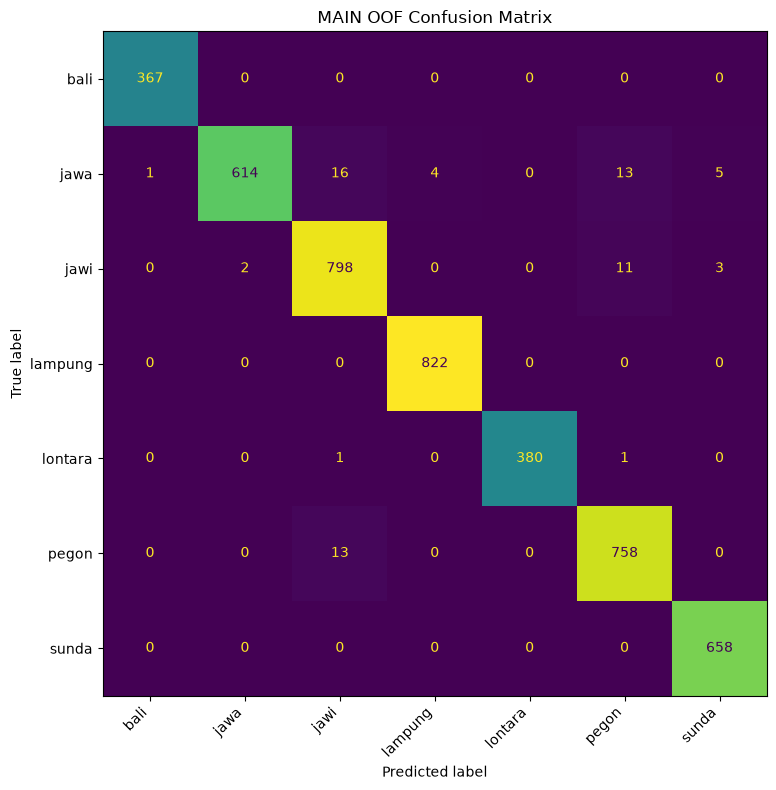

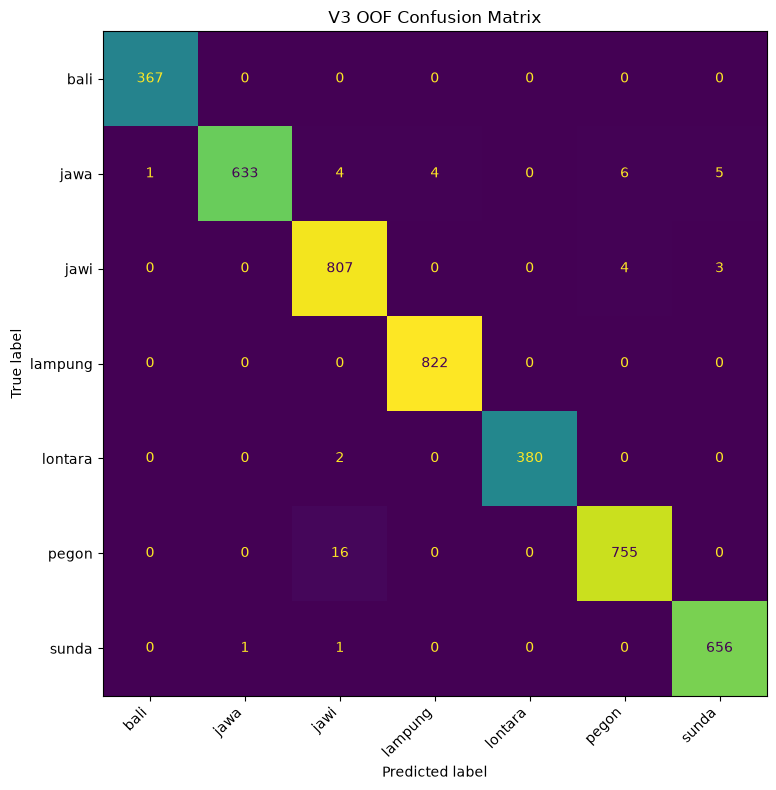

,class,main_f1,v3_f1,delta
0,bali,0.998639,0.998639,0.000000
1,jawa,0.967691,0.983683,0.015992
2,jawi,0.971985,0.981752,0.009766
3,lampung,0.997573,0.997573,0.000000
4,lontara,0.997375,0.997375,0.000000
5,pegon,0.975547,0.983073,0.007526
6,sunda,0.993958,0.992436,-0.001522


OOF predictions changed: 68/4,467
Main errors fixed by V3 : 45
Main correct broken V3  : 22


In [8]:
# ============================================================
# 8. OOF artifacts dan failure-mode comparison
# ============================================================


def save_eval_artifacts(prefix, probs, pred):
    report = classification_report(
        y_true, pred, labels=np.arange(NUM_CLASSES), target_names=CLASSES,
        output_dict=True, zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    report_df.to_csv(OUTPUT_DIR / f'{prefix}_classification_report.csv')

    cm = confusion_matrix(y_true, pred, labels=np.arange(NUM_CLASSES))
    cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)
    cm_df.to_csv(OUTPUT_DIR / f'{prefix}_confusion_matrix.csv')

    fig, ax = plt.subplots(figsize=(9, 8))
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, values_format='d', colorbar=False)
    ax.set_title(f'{prefix.upper()} OOF Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{prefix}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    return report_df, cm_df


main_report_df, main_cm_df = save_eval_artifacts('main', main_oof_probs, main_oof_pred)
v3_report_df, v3_cm_df = save_eval_artifacts('v3', v3_oof_probs, v3_oof_pred)

per_class_compare = pd.DataFrame({
    'class': CLASSES,
    'main_f1': [float(main_report_df.loc[c, 'f1-score']) for c in CLASSES],
    'v3_f1': [float(v3_report_df.loc[c, 'f1-score']) for c in CLASSES],
})
per_class_compare['delta'] = per_class_compare['v3_f1'] - per_class_compare['main_f1']
per_class_compare.to_csv(OUTPUT_DIR / 'per_class_f1_comparison.csv', index=False)
display(per_class_compare)

main_oof_df = train_df[['image_id', 'label']].copy()
main_oof_df['fold'] = fold_assignment
main_oof_df['pred_label'] = [IDX_TO_CLASS[i] for i in main_oof_pred]
for i, c in enumerate(CLASSES):
    main_oof_df[f'prob_{c}'] = main_oof_probs[:, i]
main_oof_df.to_csv(OUTPUT_DIR / 'main_oof_predictions.csv', index=False)

specialist_oof_df = train_df[['image_id', 'label']].copy()
specialist_oof_df['fold'] = fold_assignment
for i, c in enumerate(TRIO_CLASSES):
    specialist_oof_df[f'prob_{c}'] = specialist_oof_probs[:, i]
specialist_oof_df['specialist_pred'] = [TRIO_IDX_TO_CLASS[i] for i in specialist_oof_probs.argmax(1)]
specialist_oof_df.to_csv(OUTPUT_DIR / 'specialist_oof_probabilities.csv', index=False)

v3_oof_df = train_df[['image_id', 'label']].copy()
v3_oof_df['fold'] = fold_assignment
v3_oof_df['main_pred'] = [IDX_TO_CLASS[i] for i in main_oof_pred]
v3_oof_df['v3_pred'] = [IDX_TO_CLASS[i] for i in v3_oof_pred]
v3_oof_df['main_correct'] = (v3_oof_df['label'] == v3_oof_df['main_pred']).astype(int)
v3_oof_df['v3_correct'] = (v3_oof_df['label'] == v3_oof_df['v3_pred']).astype(int)
v3_oof_df['prediction_changed'] = (v3_oof_df['main_pred'] != v3_oof_df['v3_pred']).astype(int)
for i, c in enumerate(CLASSES):
    v3_oof_df[f'prob_{c}'] = v3_oof_probs[:, i]
v3_oof_df.to_csv(OUTPUT_DIR / 'v3_oof_predictions.csv', index=False)

changed_oof = v3_oof_df[v3_oof_df['prediction_changed'] == 1].copy()
changed_oof.to_csv(OUTPUT_DIR / 'v3_oof_changed_predictions.csv', index=False)

print(f'OOF predictions changed: {len(changed_oof):,}/{len(train_df):,}')
print('Main errors fixed by V3 :', int(((v3_oof_df.main_correct == 0) & (v3_oof_df.v3_correct == 1)).sum()))
print('Main correct broken V3  :', int(((v3_oof_df.main_correct == 1) & (v3_oof_df.v3_correct == 0)).sum()))

## 9. Test fusion dan submission

Test prediction menggunakan rata-rata probabilitas 5 fold untuk model utama dan rata-rata probabilitas 5 fold untuk specialist. Conditional fusion kemudian diterapkan satu kali pada dua ensemble tersebut menggunakan `alpha` yang dipilih dari OOF. Tidak ada threshold atau manual correction berbasis test.

In [9]:
# ============================================================
# 9. Test ensemble fusion dan submission files
# ============================================================

v3_test_probs = conditional_trio_fusion(main_test_probs, specialist_test_probs, SELECTED_ALPHA)
main_test_pred = main_test_probs.argmax(1)
v3_test_pred = v3_test_probs.argmax(1)

main_pred_df = pd.DataFrame({
    'image_id': test_df['image_id'].values,
    'label': [IDX_TO_CLASS[i] for i in main_test_pred],
})
v3_pred_df = pd.DataFrame({
    'image_id': test_df['image_id'].values,
    'label': [IDX_TO_CLASS[i] for i in v3_test_pred],
})

submission_main = sample_submission[['image_id']].merge(main_pred_df, on='image_id', how='left', validate='one_to_one')
submission_v3 = sample_submission[['image_id']].merge(v3_pred_df, on='image_id', how='left', validate='one_to_one')

for name, sub in [('main', submission_main), ('v3', submission_v3)]:
    assert len(sub) == len(sample_submission)
    assert sub['label'].notna().all()
    assert set(sub['label']).issubset(set(CLASSES))
    assert sub['image_id'].equals(sample_submission['image_id'])

main_submission_path = OUTPUT_DIR / 'submission_v1_rebuilt.csv'
v3_submission_path = OUTPUT_DIR / 'submission_v3_candidate.csv'
submission_main.to_csv(main_submission_path, index=False)
submission_v3.to_csv(v3_submission_path, index=False)

main_test_prob_df = test_df[['image_id']].copy()
v3_test_prob_df = test_df[['image_id']].copy()
specialist_test_prob_df = test_df[['image_id']].copy()
for i, c in enumerate(CLASSES):
    main_test_prob_df[f'prob_{c}'] = main_test_probs[:, i]
    v3_test_prob_df[f'prob_{c}'] = v3_test_probs[:, i]
for i, c in enumerate(TRIO_CLASSES):
    specialist_test_prob_df[f'prob_{c}'] = specialist_test_probs[:, i]
main_test_prob_df['pred_label'] = [IDX_TO_CLASS[i] for i in main_test_pred]
v3_test_prob_df['pred_label'] = [IDX_TO_CLASS[i] for i in v3_test_pred]
specialist_test_prob_df['specialist_pred'] = [TRIO_IDX_TO_CLASS[i] for i in specialist_test_probs.argmax(1)]

main_test_prob_df.to_csv(OUTPUT_DIR / 'main_test_probabilities.csv', index=False)
specialist_test_prob_df.to_csv(OUTPUT_DIR / 'specialist_test_probabilities.csv', index=False)
v3_test_prob_df.to_csv(OUTPUT_DIR / 'v3_test_probabilities.csv', index=False)

changed_mask = main_test_pred != v3_test_pred
changed_test = pd.DataFrame({
    'image_id': test_df.loc[changed_mask, 'image_id'].values,
    'main_pred': [IDX_TO_CLASS[i] for i in main_test_pred[changed_mask]],
    'v3_pred': [IDX_TO_CLASS[i] for i in v3_test_pred[changed_mask]],
    'main_confidence': main_test_probs[changed_mask].max(1),
    'v3_confidence': v3_test_probs[changed_mask].max(1),
})
changed_test.to_csv(OUTPUT_DIR / 'v3_test_changed_predictions.csv', index=False)

print(f'Selected alpha             : {SELECTED_ALPHA:.2f}')
print(f'Test predictions changed   : {changed_mask.sum():,}/{len(test_df):,}')
print(f'Main submission            : {main_submission_path}')
print(f'V3 candidate submission    : {v3_submission_path}')
print('\nV3 test prediction distribution:')
print(submission_v3['label'].value_counts().reindex(CLASSES, fill_value=0))

Selected alpha             : 1.00
Test predictions changed   : 19/1,118
Main submission            : /workspace/infest_v3_trio_specialist/submission_v1_rebuilt.csv
V3 candidate submission    : /workspace/infest_v3_trio_specialist/submission_v3_candidate.csv

V3 test prediction distribution:
label
bali        92
jawa       176
jawi       209
lampung    200
lontara     96
pegon      185
sunda      160
Name: count, dtype: int64


## 10. Decision summary dan artifact manifest

Notebook tidak otomatis mengklaim V3 lebih baik hanya karena specialist selesai dilatih. `RECOMMEND_SUBMIT_V3` hanya `True` bila selected `alpha > 0`, full OOF mencapai minimal `0.9860`, gain terjadi pada minimal 4/5 folds, dan mean F1 kelas Jawa/Jawi/Pegon meningkat dibanding V1.

In [10]:
# ============================================================
# 10. Decision summary, reproducibility metadata, final checks
# ============================================================

config = {
    'version': 'v3_conditional_trio_specialist',
    'seed': SEED,
    'n_splits': N_SPLITS,
    'classes': CLASSES,
    'trio_classes': TRIO_CLASSES,
    'main': {
        'model': 'torchvision_efficientnet_b0_imagenet1k_v1_full_finetune',
        'input_size': [MAIN_IMG_H, MAIN_IMG_W],
        'train_batch': MAIN_TRAIN_BATCH,
        'eval_batch': MAIN_EVAL_BATCH,
    },
    'specialist': {
        'model': 'torchvision_efficientnet_b0_imagenet1k_v1_full_finetune',
        'input_size': [SPECIALIST_IMG_H, SPECIALIST_IMG_W],
        'train_batch': SPECIALIST_TRAIN_BATCH,
        'eval_batch': SPECIALIST_EVAL_BATCH,
    },
    'optimization': {
        'max_epochs': MAX_EPOCHS,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'warmup_epochs': WARMUP_EPOCHS,
        'backbone_lr': BACKBONE_LR,
        'head_lr': HEAD_LR,
        'min_lr_ratio': MIN_LR_RATIO,
        'weight_decay': WEIGHT_DECAY,
        'label_smoothing': LABEL_SMOOTHING,
        'grad_clip_norm': GRAD_CLIP_NORM,
        'amp_fp16': USE_AMP,
        'class_weighting': False,
    },
    'fusion': {
        'type': 'conditional_geometric_interpolation_preserving_trio_mass',
        'alpha_grid': ALPHA_GRID,
        'selected_alpha': SELECTED_ALPHA,
    },
}
with open(OUTPUT_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

decision = {
    'baseline_public_lb_reference': 0.96082,
    'main_oof_macro_f1': float(main_oof_f1),
    'v3_oof_macro_f1': float(v3_oof_f1),
    'oof_gain': float(v3_oof_f1 - main_oof_f1),
    'main_trio_class_macro_f1': float(main_trio_f1),
    'v3_trio_class_macro_f1': float(v3_trio_f1),
    'selected_alpha': SELECTED_ALPHA,
    'positive_folds': positive_folds,
    'main_trio_fold_std': float(main_trio_fold_std),
    'v3_trio_fold_std': float(v3_trio_fold_std),
    'test_prediction_changes': int(changed_mask.sum()),
    'gates': {
        'alpha_nonzero': bool(gate_alpha_nonzero),
        'oof_at_least_0_9860': bool(gate_absolute_oof),
        'positive_at_least_4_of_5_folds': bool(gate_positive_folds),
        'trio_f1_improves': bool(gate_trio_improves),
    },
    'recommend_submit_v3': bool(RECOMMEND_SUBMIT_V3),
    'recommended_file_if_true': str(v3_submission_path),
    'fallback_reference_file': str(main_submission_path),
}
with open(OUTPUT_DIR / 'v3_decision.json', 'w') as f:
    json.dump(decision, f, indent=2)

summary_df = pd.DataFrame([
    {'model': 'V1 main', 'oof_macro_f1': main_oof_f1, 'trio_class_macro_f1': main_trio_f1},
    {'model': f'V3 alpha={SELECTED_ALPHA:.2f}', 'oof_macro_f1': v3_oof_f1, 'trio_class_macro_f1': v3_trio_f1},
])
summary_df.to_csv(OUTPUT_DIR / 'v3_summary.csv', index=False)
display(summary_df)

expected_files = [
    'fold_assignment.csv',
    'main_fold_metrics.csv',
    'specialist_fold_metrics.csv',
    'fusion_grid_metrics.csv',
    'paired_fold_comparison.csv',
    'per_class_f1_comparison.csv',
    'main_oof_predictions.csv',
    'specialist_oof_probabilities.csv',
    'v3_oof_predictions.csv',
    'v3_oof_changed_predictions.csv',
    'main_classification_report.csv',
    'v3_classification_report.csv',
    'main_confusion_matrix.csv',
    'v3_confusion_matrix.csv',
    'main_test_probabilities.csv',
    'specialist_test_probabilities.csv',
    'v3_test_probabilities.csv',
    'v3_test_changed_predictions.csv',
    'submission_v1_rebuilt.csv',
    'submission_v3_candidate.csv',
    'config.json',
    'v3_decision.json',
    'v3_summary.csv',
]
missing = [name for name in expected_files if not (OUTPUT_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f'Artifact output belum lengkap: {missing}')

manifest = []
for name in expected_files:
    path = OUTPUT_DIR / name
    manifest.append({
        'file': name,
        'bytes': path.stat().st_size,
        'sha256': sha256_file(path),
    })
pd.DataFrame(manifest).to_csv(OUTPUT_DIR / 'artifact_manifest.csv', index=False)

print('\n' + '=' * 90)
print('FINAL DECISION')
print('=' * 90)
if RECOMMEND_SUBMIT_V3:
    print('STATUS: V3 PASSES ACCEPTANCE GATE')
    print(f'Submit candidate: {v3_submission_path}')
else:
    print('STATUS: V3 DOES NOT PASS ACCEPTANCE GATE')
    print('Jangan gunakan slot submission hanya karena run selesai. Pertahankan V1 sebagai reference terbaik.')
    print(f'V3 candidate tetap tersedia untuk audit: {v3_submission_path}')
print(f'Decision JSON: {OUTPUT_DIR / "v3_decision.json"}')
print(f'Artifact manifest: {OUTPUT_DIR / "artifact_manifest.csv"}')

,model,oof_macro_f1,trio_class_macro_f1
0,V1 main,0.986110,0.971741
1,V3 alpha=1.00,0.990647,0.982836



FINAL DECISION
STATUS: V3 PASSES ACCEPTANCE GATE
Submit candidate: /workspace/infest_v3_trio_specialist/submission_v3_candidate.csv
Decision JSON: /workspace/infest_v3_trio_specialist/v3_decision.json
Artifact manifest: /workspace/infest_v3_trio_specialist/artifact_manifest.csv
